# Лабораторная работа №9
## Алгоритм Гриффина-Лимма

по курсу Цифровая обработка сигналов

**направление**: Речевые технологии и машинное обучение

**преподаватель**: Рыбин Сергей Витальевич

**выполнил**: Юдин Артём Андреевич

**группа**: М4121


In [1]:
import librosa
import IPython.display as ipd
import numpy as np
import itertools as it
import matplotlib.pyplot as plt

In [2]:
wav, sr = librosa.load("./voice.wav")
ipd.display(ipd.Audio(wav, rate=sr))

In [ ]:
def compute_snr(orig: np.ndarray, reconstructed: np.ndarray) -> float:
    # обрезка
    trim_len = min(len(orig), len(reconstructed))
    orig = orig[:trim_len]
    reconstructed = reconstructed[:trim_len]

    # нормализация
    orig = orig / np.max(np.abs(orig))
    reconstructed = reconstructed / np.max(np.abs(reconstructed))

    signal_power = np.mean(orig**2)

    # масштабирование
    scale = np.sqrt(signal_power / np.mean(reconstructed**2))
    reconstructed = reconstructed * scale
    noise = orig - reconstructed
    noise_power = np.mean(noise**2)
    return 10 * np.log10(signal_power / noise_power)


def griffin_lim(wav: np.ndarray, n_iter: int, n_fft: int, hop_length: int, window: str = "hann") -> np.ndarray:
    stft_original = librosa.stft(
        wav,
        n_fft=n_fft,
        hop_length=hop_length,
        win_length=n_fft,
        window=window,
    )

    magnitude_original = np.abs(stft_original)
    phase_fake = 2 * np.pi * np.random.rand(*magnitude_original.shape)
    stft_fake = magnitude_original * np.exp(1j * phase_fake)

    for _ in range(n_iter):
        audio_fake = librosa.istft(
            stft_fake,
            hop_length=hop_length,
            win_length=n_fft,
            window=window,
        )

        stft_fake = librosa.stft(
            audio_fake,
            n_fft=n_fft,
            hop_length=hop_length,
            win_length=n_fft,
            window=window,
        )

        phase_iter = np.angle(stft_fake)
        stft_fake = magnitude_original * np.exp(1j * phase_iter)

    reconstructed = librosa.istft(
        stft_fake,
        hop_length=hop_length,
        win_length=n_fft,
        window=window,
    )
    return reconstructed

In [ ]:
pre_emphasis = 0.97

n_ffts = [512 * 2**i for i in range(4)]
n_iters = [16 * 2**i for i in range(4)]
hop_length_vars = ["one forth", "one half", "equal"]

best_snr = float("-inf")
params = None
best_reconstructed = None

for n_iter, n_fft, hop_length_var in it.product(n_iters, n_ffts, hop_length_vars):
    for do_pre_ephasis in (True, False):
        np.random.seed(42)
        if do_pre_ephasis:
            wav = librosa.effects.preemphasis(wav, coef=pre_emphasis)

        match hop_length_var:
            case "one forth":
                hop_length = n_fft // 4
            case "one half":
                hop_length = n_fft // 2
            case "equal":
                hop_length = n_fft

        reconstructed_wav = griffin_lim(wav, n_iter, n_fft, hop_length)
        if do_pre_ephasis:
            wav = librosa.effects.deemphasis(wav, coef=pre_emphasis)
            reconstructed_wav = librosa.effects.deemphasis(reconstructed_wav, coef=pre_emphasis)

        snr = compute_snr(wav, reconstructed_wav)
        # print(f"N = {n_fft}, h = {hop_length}, i_max = {n_iter}, SNR = {snr:.4f}")

        if best_snr < snr:
            best_snr = snr
            params = {
                "n_fft": n_fft,
                "hop_length": hop_length,
                "n_iter": n_iter,
                "do_pre_ephasis": do_pre_ephasis,
            }
            best_reconstructed = reconstructed_wav

print("Best SNR:", best_snr)
for k, v in params.items():
    print(f"{k}: {v}")

Best SNR: -1.389557321848633
n_fft: 2048
hop_length: 512
n_iter: 128
do_pre_ephasis: False


In [5]:
print("Original")
ipd.display(ipd.Audio(wav, rate=sr))

print("Reconstructed")
ipd.display(ipd.Audio(best_reconstructed, rate=sr))

Original


Reconstructed


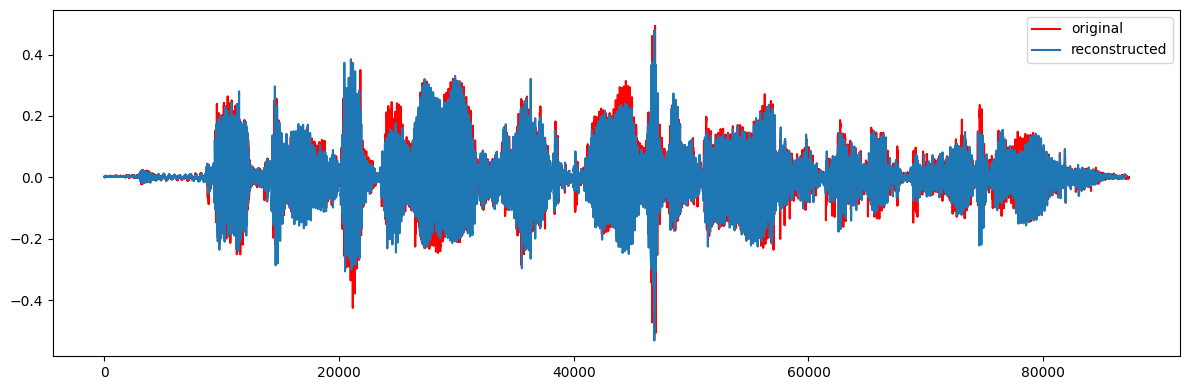

In [6]:
plt.figure(figsize=(12, 4))
plt.plot(wav, color="red", label="original")
plt.plot(best_reconstructed, label="reconstructed")

plt.legend()
plt.tight_layout()
plt.show()

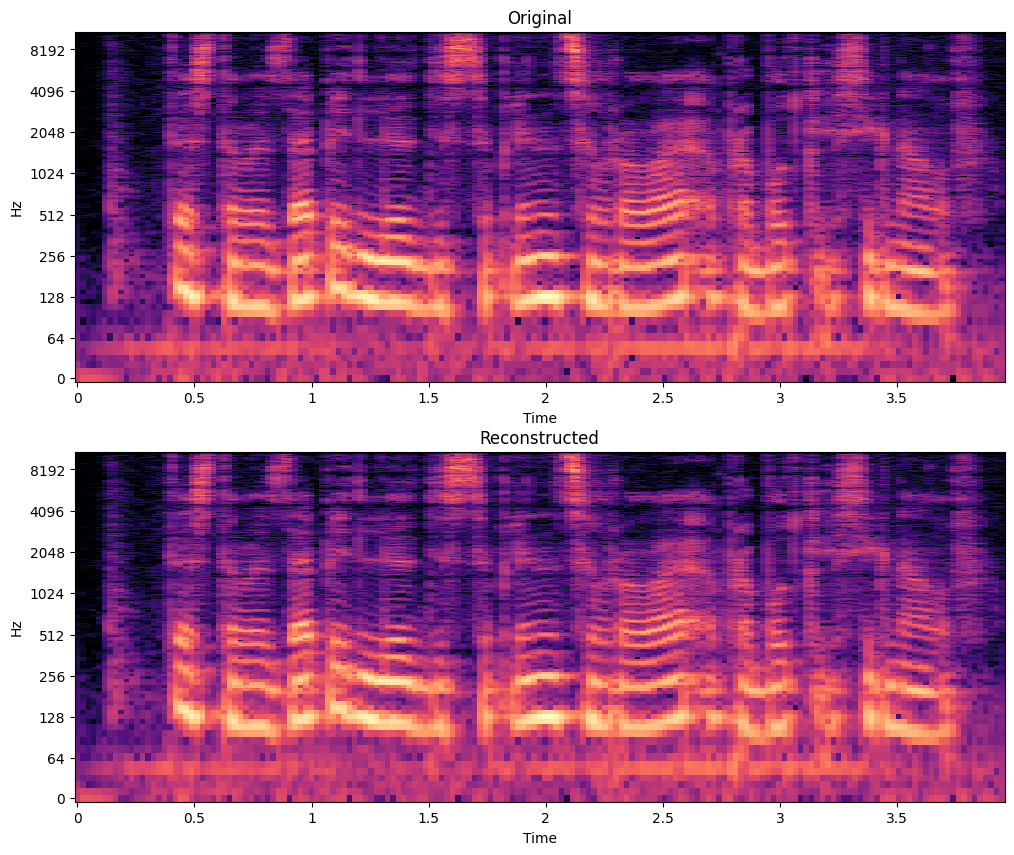

In [7]:
def plot_spec(ax, wav: np.ndarray, n_fft: int, hop_length: int, title: str) -> None:
    stft = librosa.stft(wav, n_fft=n_fft, hop_length=hop_length)
    spectrogram = librosa.amplitude_to_db(np.abs(stft), ref=np.max)
    librosa.display.specshow(
        spectrogram,
        sr=sr,
        hop_length=hop_length,
        x_axis="time",
        y_axis="log",
        ax=ax,
    )
    ax.set_title(title)


_, axes = plt.subplots(2, 1, figsize=(12, 10))
wavs = [wav, best_reconstructed]
names = ["Original", "Reconstructed"]

for i in range(2):
    plot_spec(
        axes[i],
        wavs[i],
        n_fft=params["n_fft"],
        hop_length=params["hop_length"],
        title=names[i],
    )


plt.show()